
En este notebook se trabaja con el dataset Iris utilizando técnicas de 
aprendizaje automático supervisado.  
El objetivo es comparar el desempeño de dos algoritmos de clasificación:

- K-Nearest Neighbors (K-NN)
- Árbol de Decisión

El análisis incluye:
- Exploración de datos (EDA)
- Entrenamiento de modelos
- Evaluación de precisión
- Comparación de resultados


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Dataset utilizado: Iris

Se utiliza el dataset Iris, incluido en la librería `scikit-learn`, que contiene
150 observaciones de flores Iris clasificadas en tres especies:

- Setosa
- Versicolor
- Virginica

Cada observación incluye cuatro características numéricas:
- Largo del sépalo
- Ancho del sépalo
- Largo del pétalo
- Ancho del pétalo


In [2]:
from sklearn.datasets import load_iris

iris = load_iris()

In [3]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [4]:
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target

In [5]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [6]:

df["species"] = df["species"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})



## Análisis Exploratorio de Datos (EDA)

Antes de entrenar los modelos se realizó un análisis exploratorio para:

- Verificar la calidad de los datos
- Analizar la distribución de las variables
- Observar la separabilidad entre clases

Del análisis se observa que:
- El dataset no contiene valores nulos
- Las clases están perfectamente balanceadas
- Las variables relacionadas con los pétalos presentan mayor capacidad de separación
entre las especies


In [7]:
df["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [9]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


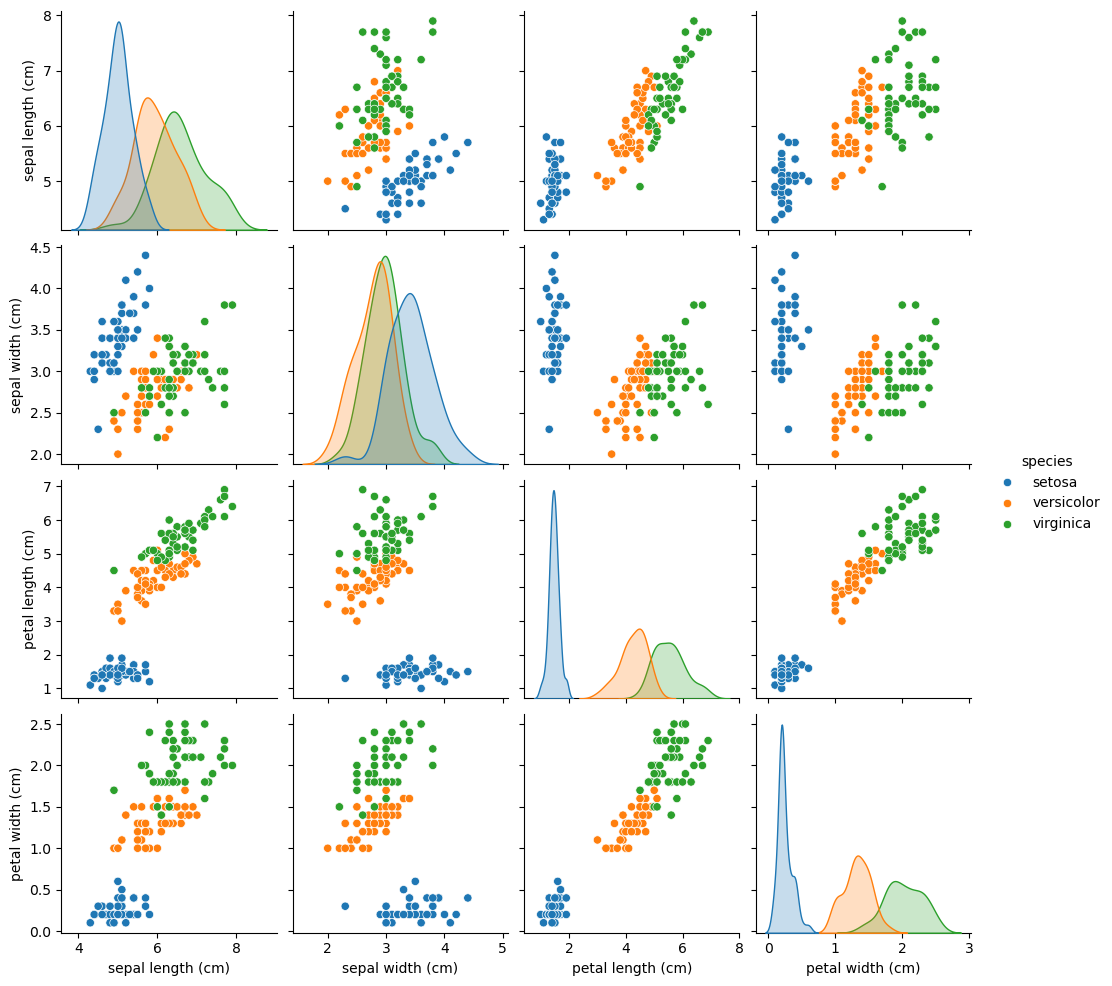

In [10]:
sns.pairplot(df, hue="species")
plt.show()

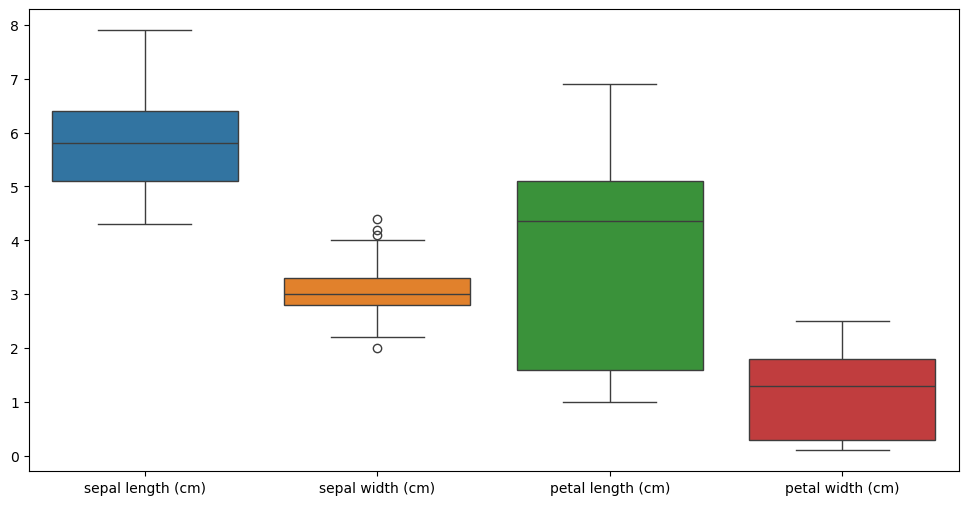

In [11]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.drop(columns="species"))
plt.show()

<Axes: xlabel='species', ylabel='petal width (cm)'>

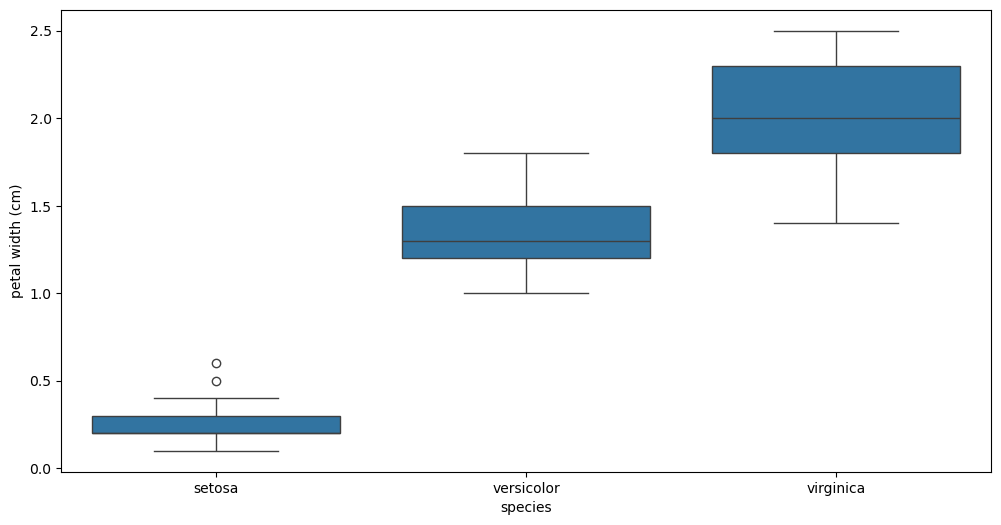

In [13]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="species", y="petal width (cm)", data=df)

In [15]:
X = df.drop(columns="species")
y = df["species"]

X = df.drop(columns="species")
y = df["species"]


## Modelo de Clasificación: K-Nearest Neighbors (K-NN)

Se implementó el algoritmo K-NN utilizando `scikit-learn`.
El modelo clasifica cada observación según las clases de sus vecinos más cercanos.

Se evaluaron dos variantes:
- Pesos uniformes
- Pesos en función de la distancia

El modelo obtuvo una alta precisión, lo que indica que el dataset presenta una
estructura adecuada para este tipo de algoritmo.


In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


In [18]:
X_train.shape, X_test.shape

((105, 4), (45, 4))

In [19]:
from sklearn.neighbors import KNeighborsClassifier

In [20]:
knn_uniform = KNeighborsClassifier(
    n_neighbors=15,
    weights="uniform"
)

In [21]:
knn_uniform.fit(X_train, y_train)

,n_neighbors,15
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [22]:
accuracy_uniform = knn_uniform.score(X_test, y_test)
accuracy_uniform

0.9555555555555556

In [23]:
knn_distance = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance"
)

knn_distance.fit(X_train, y_train)


,n_neighbors,15
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [24]:
accuracy_distance = knn_distance.score(X_test, y_test)
accuracy_distance


0.9777777777777777

In [26]:
print("Precisión K-NN (uniform):", accuracy_uniform)

Precisión K-NN (uniform): 0.9555555555555556



## Modelo de Clasificación: Árbol de Decisión

Se entrenó un modelo de Árbol de Decisión limitando la profundidad del árbol
para evitar sobreajuste.

Este modelo permite:
- Interpretar las reglas de decisión
- Analizar la importancia de cada característica

El Árbol de Decisión obtuvo una precisión levemente inferior a K-NN, pero ofrece
una ventaja clara en términos de interpretabilidad del modelo.


In [27]:
from sklearn.tree import DecisionTreeClassifier

In [28]:
dt_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

In [29]:
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [30]:

dt_accuracy = dt_model.score(X_test, y_test)
dt_accuracy


0.8888888888888888

In [31]:
feature_importance = pd.Series(
    dt_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance

petal length (cm)    0.549020
petal width (cm)     0.436488
sepal width (cm)     0.014493
sepal length (cm)    0.000000
dtype: float64

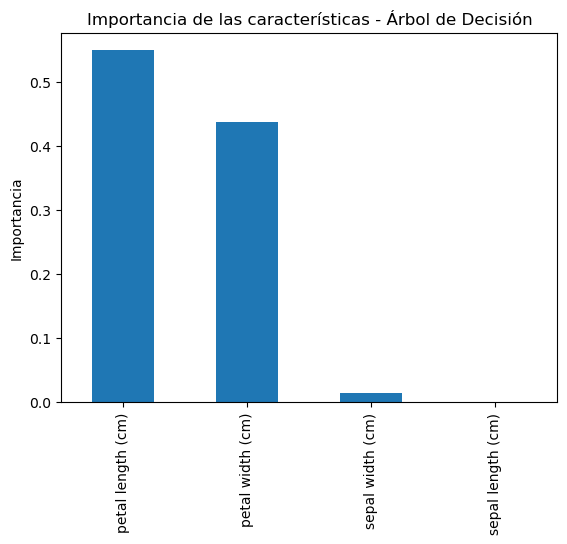

In [32]:
feature_importance.plot(kind="bar")
plt.title("Importancia de las características - Árbol de Decisión")
plt.ylabel("Importancia")
plt.show()

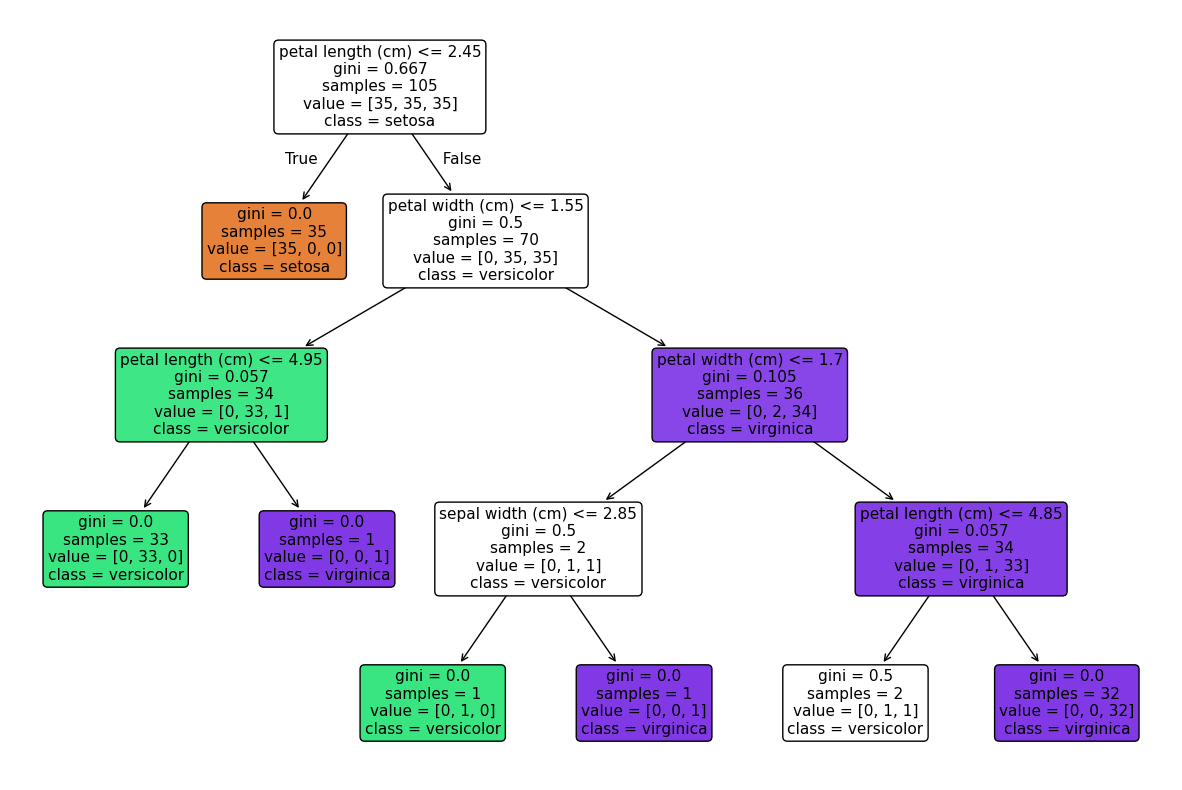

In [33]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=dt_model.classes_,
    filled=True,
    rounded=True
)
plt.show()

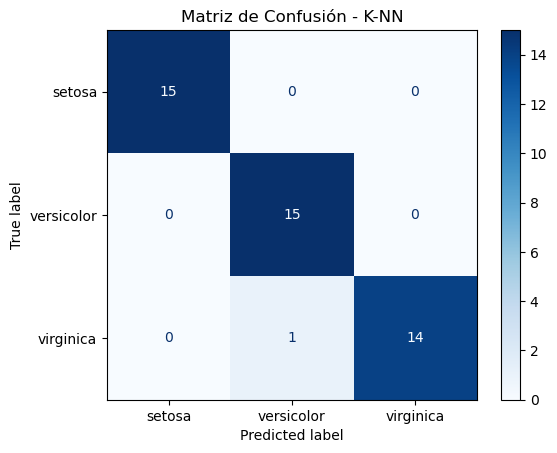

In [36]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predicciones con K-NN (el mejor que hayas usado, por ejemplo distance)
y_pred_knn = knn_distance.predict(X_test)

cm_knn = confusion_matrix(y_test, y_pred_knn)

disp_knn = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=knn_distance.classes_
)

disp_knn.plot(cmap="Blues")
plt.title("Matriz de Confusión - K-NN")
plt.show()


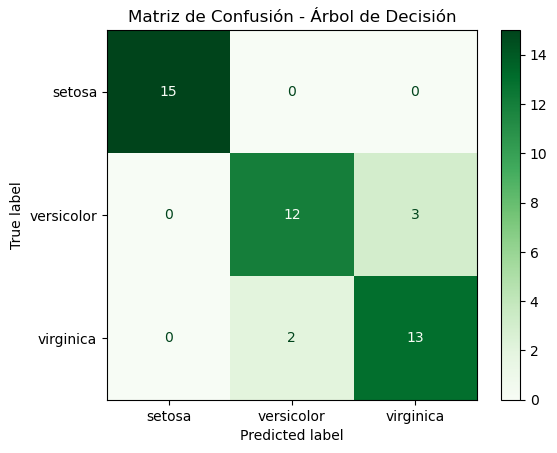

In [35]:

# Predicciones con Árbol de Decisión
y_pred_dt = dt_model.predict(X_test)

cm_dt = confusion_matrix(y_test, y_pred_dt)

disp_dt = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=dt_model.classes_
)

disp_dt.plot(cmap="Greens")
plt.title("Matriz de Confusión - Árbol de Decisión")
plt.show()


Conclusiones
Ambos modelos obtuvieron buenos resultados sobre el dataset Iris.

K-NN mostró una precisión elevada y un buen desempeño general
El Árbol de Decisión ofreció mayor interpretabilidad, identificando al ancho y largo del pétalo como variables clave
La elección del modelo dependerá del contexto del problema y de la necesidad de interpretar las decisiones del modelo.